In [27]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Information is stored in folders 'date1', 'date2' etc. In each such a folder there are subfolders with customers' 
# names with data.csv file. Create a pandas dataframe that combines all csv's together with name and date.

# a path to main folder
path = '/mnt/HC_Volume_18315164/home-jupyter/jupyter-i-mihajlova/shared/homeworks/python_ds_miniprojects/4/data/'

os.listdir(path)

['2020-12-05',
 '2020-12-08',
 '2020-12-09',
 '2020-12-04',
 '2020-12-06',
 '2020-12-03',
 '2020-12-07']

In [3]:
dates = [date.strip() for date in os.listdir(path) if not date.startswith('.')]

In [60]:
def create_df(name, date):
    df = pd.read_csv(path + date + '/' + name + '/data.csv')
    df['date'] = date
    df['name'] = name
    return df

In [61]:
big_df = pd.DataFrame([])


In [62]:
for date in dates:
    names = [name.strip() for name in os.listdir(path + date) if not name.startswith('.')]
    for name in names:
        df = create_df(name, date)
        big_df = pd.concat([big_df, df], ignore_index=True)

big_df        

,Unnamed: 0,product_id,quantity,date,name
0,0,27,4,2020-12-05,Petr_Ivanov
1,1,89,1,2020-12-05,Petr_Ivanov
2,2,33,2,2020-12-05,Petr_Ivanov
3,3,8,3,2020-12-05,Petr_Ivanov
4,4,16,1,2020-12-05,Petr_Ivanov
...,...,...,...,...,...
156,0,18,4,2020-12-07,Petr_Fedorov
157,1,94,4,2020-12-07,Petr_Fedorov
158,0,95,2,2020-12-07,Vasiliy_Ivanov
159,1,83,3,2020-12-07,Vasiliy_Ivanov


In [14]:
big_df.columns

Index(['Unnamed: 0', 'product_id', 'quantity', 'date', 'name'], dtype='object')

In [68]:
big_df = big_df.drop(columns = 'Unnamed: 0')

In [69]:
big_df.quantity.sum()

480

In [24]:
# Find all customers with maximum purchases
big_df.groupby('name', as_index=False)\
    .agg({'quantity': 'sum'})\
    .sort_values('quantity', ascending=False)

,name,quantity
3,Alexey_Smirnov,52
13,Petr_Smirnov,52
6,Anton_Smirnov,45
10,Petr_Fedorov,34
7,Kirill_Fedorov,28
16,Rostislav_Petrov,28
19,Vasiliy_Ivanov,27
0,Alexey_Fedorov,24
4,Anton_Ivanov,23
11,Petr_Ivanov,21


In [28]:
# find top-10 selling goods and construct a barplot
bestsellers = big_df.groupby('product_id', as_index=False)\
    .agg({'quantity': 'sum'})\
    .sort_values('quantity', ascending=False)\
    .head(10)

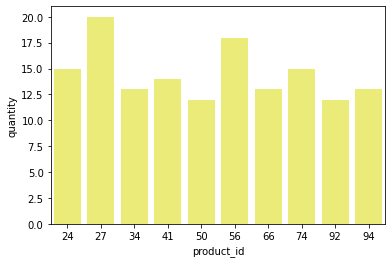

In [35]:
sns.barplot(x='product_id', y='quantity', data=bestsellers, 
            alpha=0.6, color='yellow')

In [39]:
bestsellers.query('product_id == 56')

,product_id,quantity
42,56,18


In [63]:
day_sellings = big_df.groupby('date', as_index=False)\
    .agg({'quantity': 'sum'})

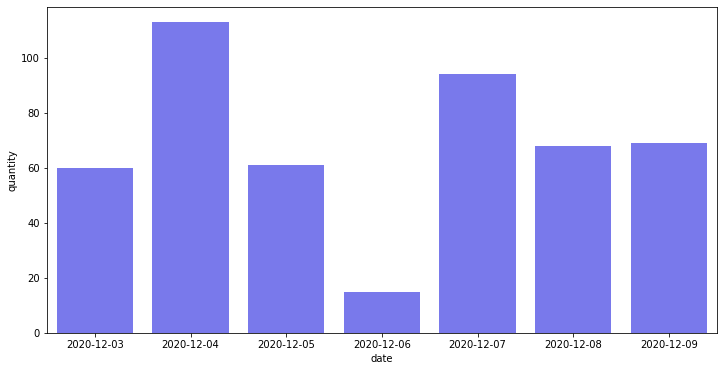

In [64]:
plt.figure(figsize=(12,6))
sns.barplot(x='date', y='quantity', data=day_sellings, color='blue', alpha=0.6)
plt.show()

In [75]:
# Find all users that purchased the same product at least twice 
# (in different days)
duplicate_purchases = big_df.loc[big_df.duplicated(subset=['name', 'product_id'], keep=False)]
duplicate_purchases

,product_id,quantity,date,name
47,55,1,2020-12-09,Alexey_Smirnov
48,55,5,2020-12-09,Alexey_Smirnov
63,15,3,2020-12-09,Anton_Ivanov
125,94,4,2020-12-03,Petr_Fedorov
155,15,4,2020-12-07,Anton_Ivanov
157,94,4,2020-12-07,Petr_Fedorov


In [76]:
# Find all duplicates with two or more dates of purchases
duplicate_purchases.groupby('name', as_index=False)\
    .agg({'date':pd.Series.nunique})\
    .query('date > 1')

,name,date
1,Anton_Ivanov,2
2,Petr_Fedorov,2
